# Machine Learning #04 — Transfer Learning in PyTorch 🦥➜🚀

In the previous lab we trained a network **from scratch**. Today we do the opposite:
we **borrow a network that someone else already trained** on millions of images and
**re-use its knowledge** for our own task. This is called **transfer learning**.

We keep the same PyTorch workflow you already know, and add the pieces that are
specific to re-using pre-trained models:

> **pre-trained model → freeze → new head → train → (fine-tune / unfreeze some layers)**

The notebook has **two parts**:

1. 🖼️ **Transfer learning on images** — re-use **ResNet50** (trained on ImageNet) to
   classify **CIFAR-10**.
2. 📈 **1D convolutions on time series** — classify engine noise (**FordA**) with `Conv1d`.

## What is transfer learning? 🔎

Transfer learning means **taking features learned on one problem and using them on a
new, similar problem**.

- A CNN trained on millions of images learns **general visual features** — edges,
  textures, shapes, parts of objects. *An edge is an edge*, no matter the final task.
- Training such a model from scratch needs **huge data + huge compute**. It would be a
  waste to throw those learned features away when our own dataset is small.

### The usual pipeline 📌

1. **Take** the layers of a previously trained model (the *backbone* / *feature extractor*).
2. **Freeze** them, so training does not destroy what they already know.
3. **Add a small new head** (trainable layers) on top and train **only the head**.
4. *(Optional)* **Fine-tune**: unfreeze all or part of the backbone and re-train with a
   **very low learning rate** to gently adapt the features to your data.

| | Train from scratch | Transfer learning |
|---|---|---|
| Data needed | a lot | **little** |
| Compute | high | **low** (only the head at first) |
| Starting point | random weights | **weights that already "see"** |
| Typical accuracy on small data | low | **high** |

> 🔎 **Think about it:** do you know any famous pre-trained CNNs? (ResNet, VGG,
> MobileNet, EfficientNet…) Why is a **low** learning rate important during fine-tuning?

## Imports and setup ⚙️
Remember to select a **GPU** runtime in Colab! (*Runtime → Change runtime type → GPU*)

In [ ]:
!pip install torchinfo

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import torchvision
from torchvision import datasets
from torchvision.models import resnet50, ResNet50_Weights

import torchinfo

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch version:", torch.__version__)
print("device:", device)

torch version: 2.6.0+cu124
device: cuda


### A tiny helper we will reuse everywhere 🔧

Two utilities used across the whole notebook:

- `count_params(model)` — prints how many parameters are **total** vs **trainable**.
  This is the single most useful thing to check in transfer learning.
- `run_epoch(...)` — one pass over a `DataLoader`; trains if an optimizer is given,
  otherwise just evaluates. It returns the average **loss** and **accuracy**.

In [6]:
def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  total parameters:     {total:,}")
    print(f"  trainable parameters: {trainable:,}")
    return total, trainable

In [8]:
def run_epoch(model, loader, criterion, optimizer=None, bn_frozen=False):
    is_train = optimizer is not None

    if is_train:
        model.train()
        if bn_frozen:
            for m in model.modules():
                if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
                    m.eval()
    else:
        model.eval()

    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            correct    += (logits.argmax(dim=1) == yb).sum().item()
            n          += xb.size(0)

    return total_loss / n, correct / n

---
# 🖼️ Part 1 — Transfer learning on images (ResNet50 → CIFAR-10)

## The dataset — CIFAR-10 🖼️

**CIFAR-10** contains small `32×32` colour images in **10 classes**.

| id | class | id | class |
|---|---|---|---|
| 0 | airplane ✈️ | 5 | dog 🐶 |
| 1 | automobile 🚗 | 6 | frog 🐸 |
| 2 | bird 🐦 | 7 | horse 🐴 |
| 3 | cat 🐱 | 8 | ship 🚢 |
| 4 | deer 🦌 | 9 | truck 🚚 |

In [5]:
train_full = datasets.CIFAR10(root="./data", train=True,  download=True)
test_full  = datasets.CIFAR10(root="./data", train=False, download=True)

class_names = train_full.classes
num_classes = len(class_names)

print("classes:", class_names)

classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [35]:
SUBSET_TRAIN = 2000     
SUBSET_VAL   = 1000
SUBSET_TEST  = 500

X_train = train_full.data[:SUBSET_TRAIN]                              # (2000, 32, 32, 3)
y_train = np.array(train_full.targets[:SUBSET_TRAIN])                 # (2000,)

X_val = train_full.data[SUBSET_TRAIN:SUBSET_TRAIN + SUBSET_VAL]       # (1000, 32, 32, 3)
y_val = np.array(train_full.targets[SUBSET_TRAIN:SUBSET_TRAIN + SUBSET_VAL])   # (1000,)

X_test = test_full.data[:SUBSET_TEST]                                 # (500, 32, 32, 3)
y_test = np.array(test_full.targets[:SUBSET_TEST])                    # (500,)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "| y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test.shape)

X_train: (2000, 32, 32, 3) | y_train: (2000,)
X_val  : (1000, 32, 32, 3) | y_val  : (1000,)
X_test : (500, 32, 32, 3) | y_test : (500,)


In [36]:
counts = np.bincount(y_train, minlength=num_classes)
dist = pd.DataFrame({
    "class": class_names,
    "count": counts,
    "%": (counts / counts.sum() * 100).round(1),
})
print(dist.to_string(index=False))

     class  count    %
  airplane    202 10.1
automobile    191  9.6
      bird    203 10.2
       cat    195  9.8
      deer    214 10.7
       dog    183  9.2
      frog    207 10.4
     horse    199 10.0
      ship    203 10.2
     truck    203 10.2


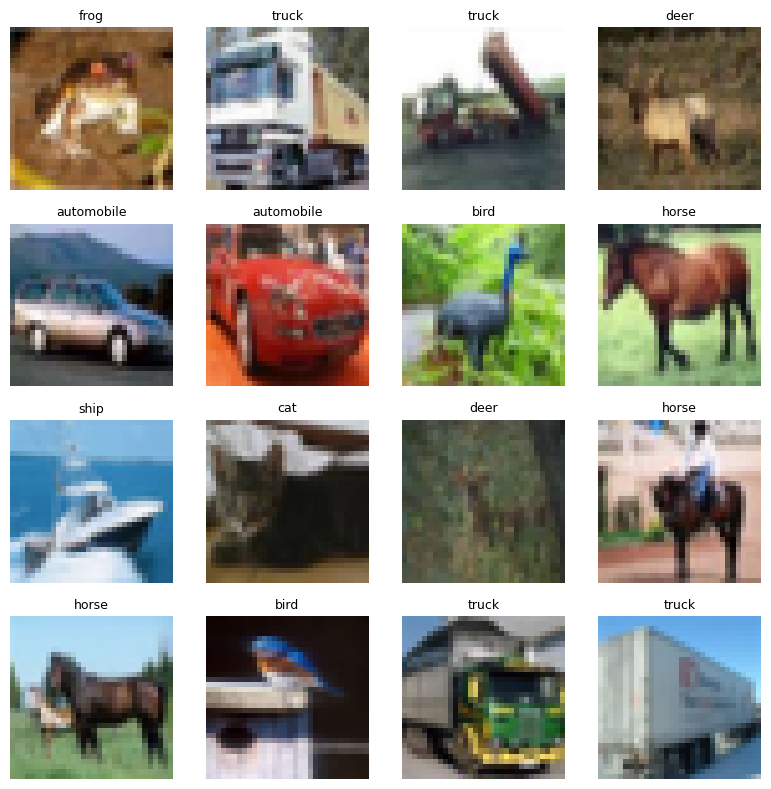

In [ ]:
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(X_train[i])                 # .data is a (N, 32, 32, 3) uint8 array
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

## The pre-trained model — ResNet50 🧠

`torchvision` ships many famous CNNs **with their trained weights**. We load **ResNet50**
trained on **ImageNet** (1000 classes, ~1.28M images).

- `weights=ResNet50_Weights.DEFAULT` downloads the **best available** ImageNet weights.
- The model has two parts:
  - a **backbone** (many convolutional blocks) → extracts features — *we want this*,
  - a **head** `model.fc` (a single `Linear` → 1000 ImageNet classes) — *we will replace this*.

In [40]:
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights).to(device)

print(model.fc)   # the classifier head: Linear(in_features=2048, out_features=1000)

Linear(in_features=2048, out_features=1000, bias=True)


In [41]:
torchinfo.summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 256, 56, 56]          --
│    └─Bottleneck: 2-1                   [1, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│ 

## Preprocessing the PyTorch way — `weights.transforms()` ✨

Every pre-trained model expects its input prepared **exactly** the way it was during
its original training (specific size + specific normalization). 

In PyTorch, the weights object **carries its own preprocessing** — one call gives you the
right resize, crop and normalization automatically. 

In [42]:
preprocess = weights.transforms()   # the SAME preprocessing ResNet50 was trained with
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [43]:
def build_tensors(images, labels):          # images: (N,32,32,3) uint8, labels: (N,)
    xs = [preprocess(Image.fromarray(img)) for img in images]  # resize+crop+normalize
    X = torch.stack(xs)                       # [N, 3, 224, 224]
    y = torch.tensor(labels, dtype=torch.long)
    return X, y

X_train_tensor, y_train_tensor = build_tensors(X_train, y_train)
X_val_tensor, y_val_tensor = build_tensors(X_val, y_val)
X_test_tensor,  y_test_tensor  = build_tensors(X_test,  y_test)

In [44]:
X_train_tensor[0]

tensor([[[-1.2274, -1.2617, -1.2959,  ...,  0.3994,  0.3823,  0.3652],
         [-1.3302, -1.3644, -1.3987,  ...,  0.3138,  0.3138,  0.2967],
         [-1.4329, -1.4672, -1.5014,  ...,  0.2624,  0.2453,  0.2453],
         ...,
         [ 0.9132,  0.8961,  0.8789,  ..., -0.1314, -0.1828, -0.2342],
         [ 0.9132,  0.8961,  0.8618,  ..., -0.0287, -0.0801, -0.1486],
         [ 0.8961,  0.8789,  0.8447,  ...,  0.0912,  0.0227, -0.0458]],

        [[-1.0728, -1.1078, -1.1429,  ...,  0.0476,  0.0476,  0.0651],
         [-1.1779, -1.2129, -1.2479,  ..., -0.0399, -0.0399, -0.0399],
         [-1.2829, -1.3179, -1.3529,  ..., -0.1275, -0.1275, -0.1275],
         ...,
         [ 0.4153,  0.3803,  0.3452,  ..., -0.5651, -0.6001, -0.6527],
         [ 0.4328,  0.3978,  0.3627,  ..., -0.4601, -0.4951, -0.5651],
         [ 0.4328,  0.3978,  0.3627,  ..., -0.3375, -0.3901, -0.4601]],

        [[-0.8284, -0.8807, -0.9156,  ..., -0.1138, -0.1138, -0.1138],
         [-0.9330, -0.9853, -1.0201,  ..., -0

## Freeze the backbone 🧊

We do not want to change the pre-trained features (yet). We **freeze** every parameter by
setting `requires_grad = False`. Frozen parameters get **no gradients** and are **not
updated** by the optimizer.


In [46]:
print("Before freezing:")
count_params(model)

Before freezing:
  total parameters:     25,557,032
  trainable parameters: 25,557,032


(25557032, 25557032)

In [47]:
for param in model.parameters():
    param.requires_grad = False

print("After freezing the whole model:")
count_params(model)

After freezing the whole model:
  total parameters:     25,557,032
  trainable parameters: 0


(25557032, 0)

## Swap the classifier head 🔁

ImageNet has 1000 classes, CIFAR-10 has **10**. We replace `model.fc` with a fresh
`Linear` layer of the right size. A newly created layer is **trainable by default**, so
suddenly we have a small number of trainable parameters again.

$$\underbrace{2048}_{\text{features from backbone}} \times \underbrace{10}_{\text{classes}} \;+\; \underbrace{10}_{\text{biases}} \;=\; 20\,490$$


In [48]:
in_features = model.fc.in_features      # 2048 for ResNet50
print(in_features)
model.fc = nn.Linear(in_features, num_classes).to(device)

print("After swapping the head:")
count_params(model)

2048
After swapping the head:
  total parameters:     23,528,522
  trainable parameters: 20,490


(23528522, 20490)

## DataLoaders 📦

In [49]:
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
val_loader  = DataLoader(TensorDataset(X_val_tensor,  y_val_tensor),  batch_size=32, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_tensor,  y_test_tensor),  batch_size=32, shuffle=False)

print("train batches:", len(train_loader), "| val batches:", len(val_loader) , "| test batches:", len(test_loader))

train batches: 63 | val batches: 32 | test batches: 16


#### Loss function and optimizer ⚖️

- **Loss:** `nn.CrossEntropyLoss` — the standard loss for **multi-class** classification.
  It takes **raw logits** (no softmax needed; it is applied internally) and integer labels.
- **Optimizer:** `Adam`, but we pass it **only the head's parameters** — the backbone is
  frozen, so there is nothing else to optimize.

> 📌 **BatchNorm note:** ResNet contains `BatchNorm` layers that track the
> mean/variance of their inputs. While the backbone is frozen we keep those statistics
> **frozen too** (`bn_frozen=True`), so they are not overwritten by CIFAR data.

In [50]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)   # only the head

#### The training loop — feature-extraction phase ⭐

Only the head learns; the backbone just **extracts features**. A handful of epochs is
usually enough because the features are already excellent.

In [ ]:
n_epochs = 3
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(n_epochs):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, bn_frozen=True)
    val_loss, val_acc = run_epoch(model, val_loader,  criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    print(f"epoch {epoch+1}/{n_epochs} | "
          f"train_acc={train_acc:.3f}  val_acc={val_acc:.3f}")

epoch 1/3 | train_acc=0.940  val_acc=0.878
epoch 2/3 | train_acc=0.950  val_acc=0.885
epoch 3/3 | train_acc=0.962  val_acc=0.887


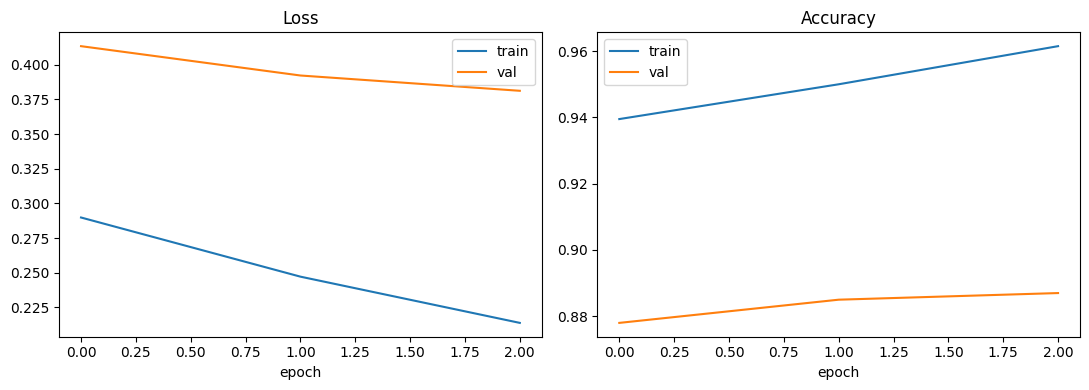

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history["train_loss"], label="train")
ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss")
ax[0].set_xlabel("epoch")
ax[0].legend()
ax[1].plot(history["train_acc"], label="train")
ax[1].plot(history["val_acc"], label="val")
ax[1].set_title("Accuracy")
ax[1].set_xlabel("epoch")

ax[1].legend()
plt.tight_layout()
plt.show()

#### Evaluation 📊
We collect predictions on the test set and report **accuracy** + a **confusion matrix**.

In [ ]:
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb.to(device)).argmax(dim=1).cpu()
        all_preds.append(preds)
        all_true.append(yb)

y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_true).numpy()

print(f"Test accuracy: {accuracy_score(y_true, y_pred):.3f}")

Test accuracy: 0.856


# Fine-tuning 🔥

Once the head has converged, we can try to **unfreeze the backbone** and continue training
the whole network end-to-end — but with a **very low learning rate**.

- **Why a tiny learning rate?** We only want to *gently nudge* the features toward our data,
  not overwrite them. Large steps ⇒ fast overfitting + loss of pre-trained knowledge.

In [56]:
# Unfreeze the whole backbone
for param in model.parameters():
    param.requires_grad = True

print("After unfreezing everything:")
count_params(model)

After unfreezing everything:
  total parameters:     23,528,522
  trainable parameters: 23,528,522


(23528522, 23528522)

In [ ]:
# A fresh optimizer over ALL parameters, with a very low learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

n_epochs = 3
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(n_epochs):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, bn_frozen=True)
    val_loss, val_acc = run_epoch(model, val_loader,  criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    print(f"epoch {epoch+1}/{n_epochs} | "
          f"train_acc={train_acc:.3f}  val_acc={val_acc:.3f}")

epoch 1/3 | train_acc=0.970  val_acc=0.914
epoch 2/3 | train_acc=0.995  val_acc=0.917
epoch 3/3 | train_acc=1.000  val_acc=0.921


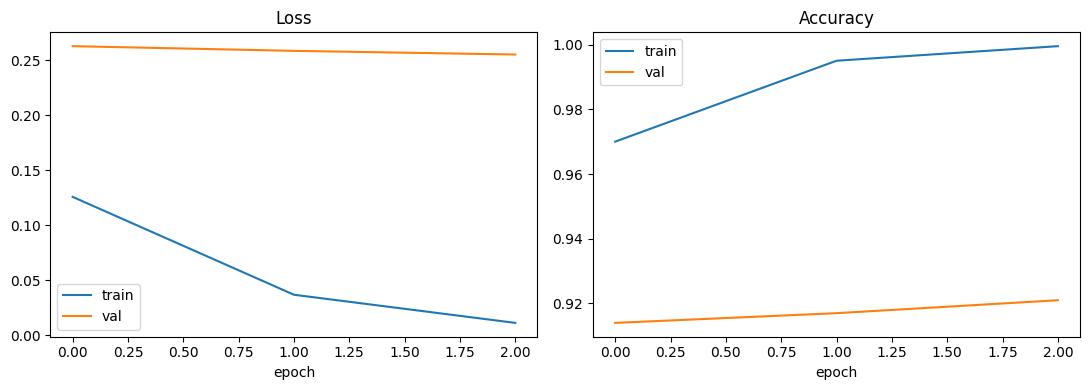

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(history["train_loss"], label="train")
ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss")
ax[0].set_xlabel("epoch")
ax[0].legend()
ax[1].plot(history["train_acc"], label="train")
ax[1].plot(history["val_acc"], label="val")
ax[1].set_title("Accuracy")
ax[1].set_xlabel("epoch")
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        all_preds.append(model(xb.to(device)).argmax(dim=1).cpu())
        all_true.append(yb)

y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_true).numpy()

print(f"Fine-tuned test accuracy: {accuracy_score(y_true, y_pred):.3f}")

Fine-tuned test accuracy: 0.918


# Training only *some* layers 🧩

Full freezing and full fine-tuning are the two extremes. In practice a **middle ground**
often works best: **freeze the early layers, train only the later blocks + the head.**

Intuition 💡:
- **Early** convolutions learn *generic* features (edges, colours) → keep them frozen.
- **Later** blocks learn *task-specific* features → let them adapt to our data.

Let's look at the top-level building blocks of ResNet50 first.

In [60]:
for name, child in model.named_children():
    print(name)
# conv1, bn1, relu, maxpool, layer1, layer2, layer3, layer4, avgpool, fc

conv1
bn1
relu
maxpool
layer1
layer2
layer3
layer4
avgpool
fc


We now **freeze everything**, then **unfreeze only `layer4` (the last block) and `fc`**.
The trainable-parameter count will land **between** "head only" and "whole model".

In [61]:
# 1) freeze all
for param in model.parameters():
    param.requires_grad = False

# 2) unfreeze the last convolutional block + the head
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

print("Training only layer4 + fc:")
count_params(model)

Training only layer4 + fc:
  total parameters:     23,528,522
  trainable parameters: 14,985,226


(23528522, 14985226)

In [ ]:
# The optimizer should only receive parameters that actually require gradients
trainable = filter(lambda p: p.requires_grad, model.parameters())
optimizer = torch.optim.Adam(trainable, lr=1e-4)

n_epochs = 3
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(n_epochs):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, bn_frozen=True)
    val_loss, val_acc = run_epoch(model, val_loader,  criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    print(f"epoch {epoch+1}/{n_epochs} | "
          f"train_acc={train_acc:.3f}  val_acc={val_acc:.3f}")

epoch 1/3 | train_acc=0.984  val_acc=0.905
epoch 2/3 | train_acc=0.990  val_acc=0.913
epoch 3/3 | train_acc=0.998  val_acc=0.894


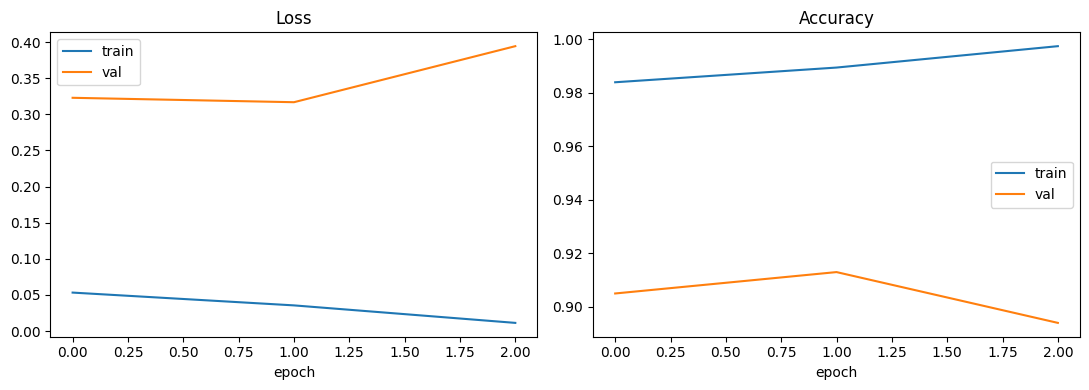

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(history["train_loss"], label="train")
ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss")
ax[0].set_xlabel("epoch")
ax[0].legend()
ax[1].plot(history["train_acc"], label="train")
ax[1].plot(history["val_acc"], label="val")
ax[1].set_title("Accuracy")
ax[1].set_xlabel("epoch")
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        all_preds.append(model(xb.to(device)).argmax(dim=1).cpu())
        all_true.append(yb)

y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_true).numpy()

print(f"Train same layers - test accuracy: {accuracy_score(y_true, y_pred):.3f}")

Train same layers - test accuracy: 0.886


### Bonus: different learning rates per part (discriminative LR) 🎚️

A neat PyTorch trick: give each part of the network **its own learning rate** using
**parameter groups**. Typically the pre-trained block gets a *smaller* LR than the fresh
head.

```python
optimizer = torch.optim.Adam([
    {"params": model.layer4.parameters(), "lr": 1e-5},   # gentle on pre-trained block
    {"params": model.fc.parameters(),     "lr": 1e-3},   # faster on the new head
])
```

# Activities — Part 1 ✏️

Now it is your turn. Use the empty cells below.

## Activity 1 — Swap the pre-trained model 🔄

Pick **another** model from `torchvision.models` (e.g. `resnet18`, `mobilenet_v3_small`,
`efficientnet_b0`). Remember to:

- import its `*_Weights` and use `weights.transforms()` for preprocessing,
- replace **its** classifier head (it may be called `model.fc` **or** `model.classifier`),
- freeze the backbone and train the head.

Compare speed and accuracy with ResNet50. Write down your conclusions.

## Activity 2 — Unfreeze a different number of blocks 🧊➜🔥

Instead of only `layer4`, try unfreezing `layer3 + layer4 + fc` (or only `fc`).
How does the **trainable-parameter count**, **training time** and **test accuracy** change?

## Activity 3 — Give the head more capacity 🏗️

Replace the single `Linear` head with a small MLP.

Does the extra capacity help, or does it overfit on our small subset?

## Activity 4 — Spot the mistake 🕵️

The training loop below runs without any error and the printed numbers even look good.
Don't run or fix anything — just read it carefully and explain.


```python
for epoch in range(n_epochs):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, bn_frozen=True)
    test_loss,  test_acc  = run_epoch(model, test_loader,  criterion)
```

- 🔎 What is the **test set** being used for in this loop?
- 🔎 Why is that a problem for the accuracy we report at the very end?

> *Write answer here.*

---
# 📈 Part 2 — 1D convolutions on time series (FordA)

You are already an expert on CNNs for **images**. The *same idea* works
on **sequences / time series** with **1D convolutions**. 🙂

| | kernel moves along | typical data |
|---|---|---|
| `Conv1d` | **1 axis** (time) | time series, audio, sensors |
| `Conv2d` | 2 axes (H, W) | images |
| `Conv3d` | 3 axes (H, W, depth) | video, MRI |

> ⚠️ **Very important PyTorch detail:** `Conv1d` expects **channels-first** input of shape
> **`(batch, channels, length)`**.

## The FordA dataset 🚗🔧

Each sample is a **500-step time series** of an engine noise measurement. The task is a
**binary** classification: is a certain fault present (`1`) or not (`0`)?

In [10]:
from sklearn.model_selection import train_test_split


In [ ]:
url = "https://github.com/rasvob/VSB-FEI-Deep-Learning-Exercises/raw/main/datasets"
train_df = pd.read_feather(f"{url}/FordA_TRAIN.feather")
test_df  = pd.read_feather(f"{url}/FordA_TEST.feather")

# original labels are -1 / 1  ->  convert to 0 / 1
train_df["target"] = train_df["target"].replace(-1, 0)
test_df["target"]  = test_df["target"].replace(-1, 0)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df["target"],
)

print("train:", train_df.shape, "| val:", val_df.shape, "| test:", test_df.shape)


train: (2880, 501) | val: (721, 501) | test: (1320, 501)


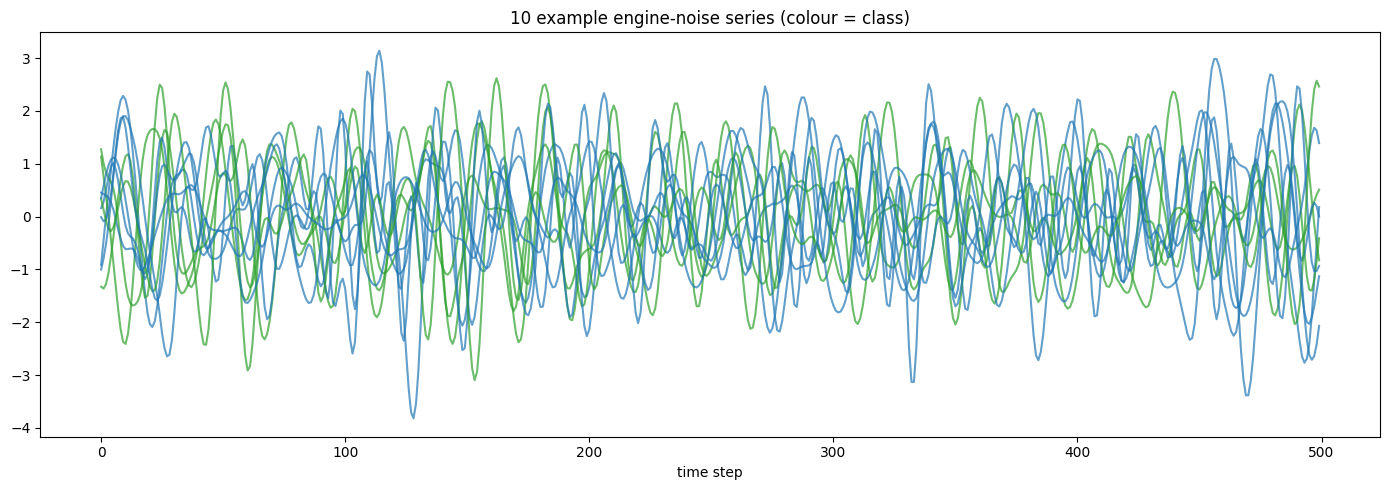

In [ ]:
# Plot a few series, coloured by class
colors = ["tab:blue", "tab:green"]
plt.figure(figsize=(14, 5))
for idx in range(10):
    label = int(train_df.iloc[idx, -1])
    plt.plot(train_df.iloc[idx, :-1].values, c=colors[label], alpha=0.7)
    
plt.title("10 example engine-noise series (colour = class)")
plt.xlabel("time step")
plt.tight_layout()
plt.show()

In [15]:
# Are the classes balanced?
print(train_df["target"].value_counts())

target
0    1476
1    1404
Name: count, dtype: int64


## Baselines with scikit-learn 🌳

Before deep learning, always get a **cheap baseline**. If a Decision Tree already scores
high, maybe you don't need a CNN at all. Here they are only *okay* — room to improve!

In [16]:
X_train = train_df.drop(columns=["target"]).values      
y_train = train_df["target"].values

X_val = val_df.drop(columns=["target"]).values
y_val = val_df["target"].values

X_test  = test_df.drop(columns=["target"]).values
y_test  = test_df["target"].values

In [17]:
for clf in [DecisionTreeClassifier(random_state=13),
            RandomForestClassifier(random_state=13)]:
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    print(f"{clf.__class__.__name__:24s} accuracy = {acc*100:5.2f}%")

DecisionTreeClassifier   accuracy = 59.09%
RandomForestClassifier   accuracy = 72.05%


## A fully-connected baseline in PyTorch 🧠

First a plain **MLP** (no convolutions) so we have a neural baseline to beat.

We reuse our `run_epoch` helper, so we build tensors and `DataLoader`s. For a **2-class**
problem we use `CrossEntropyLoss` with **2 output logits** and **long** labels (exactly like
the image part) — this keeps one single training loop for the whole notebook.

In [18]:
def make_loader(X, y, batch_size=32, shuffle=False):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader = make_loader(X_val, y_val)
test_loader  = make_loader(X_test,  y_test)

In [22]:
mlp = nn.Sequential(
    nn.Linear(500, 256), 
    nn.ReLU(), 
    nn.Dropout(0.2),
    nn.Linear(256, 64),  
    nn.ReLU(),
    nn.Linear(64, 2),                       # 2 logits -> 2 classes
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)

for epoch in range(10):
    train_loss, train_acc = run_epoch(mlp, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(mlp, val_loader,  criterion)
    print(f"epoch {epoch+1:2d}/10 | train_acc={train_acc:.3f}  val_acc={val_acc:.3f}")

epoch  1/10 | train_acc=0.643  val_acc=0.684
epoch  2/10 | train_acc=0.745  val_acc=0.712
epoch  3/10 | train_acc=0.797  val_acc=0.736
epoch  4/10 | train_acc=0.833  val_acc=0.724
epoch  5/10 | train_acc=0.867  val_acc=0.760
epoch  6/10 | train_acc=0.880  val_acc=0.768
epoch  7/10 | train_acc=0.901  val_acc=0.764
epoch  8/10 | train_acc=0.903  val_acc=0.752
epoch  9/10 | train_acc=0.903  val_acc=0.781
epoch 10/10 | train_acc=0.934  val_acc=0.804


In [ ]:
mlp.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        all_preds.append(mlp(xb.to(device)).argmax(dim=1).cpu())
        all_true.append(yb)

y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_true).numpy()

print(f"Test accuracy: {accuracy_score(y_true, y_pred):.3f}")

Test accuracy: 0.772


## Reshape for `Conv1d` — channels-first ⚠️

Our series has **1 channel** (a single measurement per time step). `Conv1d` wants
`(batch, channels, length)`, so we reshape each sample from `(500,)` to `(1, 500)`.

In [21]:
def make_conv_loader(X, y, batch_size=32, shuffle=False):
    X_t = torch.tensor(X, dtype=torch.float32).unsqueeze(1)   # (N, 500) -> (N, 1, 500)
    y_t = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

train_loader_c = make_conv_loader(X_train, y_train, shuffle=True)
val_loader_c = make_conv_loader(X_val, y_val)
test_loader_c  = make_conv_loader(X_test,  y_test)

xb, yb = next(iter(train_loader_c))
print("Conv1d input batch shape:", tuple(xb.shape))   # (32, 1, 500)  -> (batch, channels, length)

Conv1d input batch shape: (32, 1, 500)


## A single `Conv1d` layer 🌀

> 💡 **PyTorch tip:** after flattening we would need to know the exact number of features
> to size the next `Linear`. Instead of computing it by hand, we use **`nn.LazyLinear`**,
> which **infers its input size automatically** on the first forward pass. Very handy!

In [23]:
conv_small = nn.Sequential(
    nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3), nn.ReLU(),  # (N,1,500)->(N,64,498)
    nn.Flatten(),
    nn.LazyLinear(64), nn.ReLU(),      # input size inferred automatically
    nn.Linear(64, 2),
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(conv_small.parameters(), lr=1e-3)

for epoch in range(10):
    train_loss, train_acc = run_epoch(conv_small, train_loader_c, criterion, optimizer)
    val_loss, val_acc = run_epoch(conv_small, val_loader_c,  criterion)
    print(f"epoch {epoch+1:2d}/10 | train_acc={train_acc:.3f}  val_acc={val_acc:.3f}")

epoch  1/10 | train_acc=0.533  val_acc=0.559
epoch  2/10 | train_acc=0.609  val_acc=0.660
epoch  3/10 | train_acc=0.656  val_acc=0.648
epoch  4/10 | train_acc=0.692  val_acc=0.657
epoch  5/10 | train_acc=0.723  val_acc=0.669
epoch  6/10 | train_acc=0.749  val_acc=0.645
epoch  7/10 | train_acc=0.772  val_acc=0.674
epoch  8/10 | train_acc=0.785  val_acc=0.684
epoch  9/10 | train_acc=0.787  val_acc=0.689
epoch 10/10 | train_acc=0.817  val_acc=0.684


In [ ]:
conv_small.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader_c:
        all_preds.append(conv_small(xb.to(device)).argmax(dim=1).cpu())
        all_true.append(yb)
        
y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_true).numpy()
print(f"Test accuracy: {accuracy_score(y_true, y_pred):.3f}")

Test accuracy: 0.686


## A deeper `Conv1d` with pooling 🏗️

Stacking convolutions lets the network build **hierarchical** features; `MaxPool1d`
shrinks the sequence, which reduces parameters and enlarges the *receptive field*.

In [25]:
conv_deep = nn.Sequential(
    nn.Conv1d(1,  64, kernel_size=3), nn.ReLU(),
    nn.Conv1d(64, 64, kernel_size=3), nn.ReLU(),
    nn.MaxPool1d(2),
    nn.Conv1d(64, 64, kernel_size=3), nn.ReLU(),
    nn.Conv1d(64, 64, kernel_size=3), nn.ReLU(),
    nn.Flatten(),
    nn.LazyLinear(64), nn.ReLU(),
    nn.Linear(64, 2),
).to(device)

optimizer = torch.optim.Adam(conv_deep.parameters(), lr=1e-3)

for epoch in range(10):
    train_loss, train_acc = run_epoch(conv_deep, train_loader_c, criterion, optimizer)
    val_loss, val_acc = run_epoch(conv_deep, val_loader_c,  criterion)
    print(f"epoch {epoch+1:2d}/10 | train_acc={train_acc:.3f}  val_acc={val_acc:.3f}")

epoch  1/10 | train_acc=0.509  val_acc=0.513
epoch  2/10 | train_acc=0.623  val_acc=0.700
epoch  3/10 | train_acc=0.720  val_acc=0.724
epoch  4/10 | train_acc=0.792  val_acc=0.828
epoch  5/10 | train_acc=0.822  val_acc=0.803
epoch  6/10 | train_acc=0.859  val_acc=0.818
epoch  7/10 | train_acc=0.878  val_acc=0.857
epoch  8/10 | train_acc=0.894  val_acc=0.850
epoch  9/10 | train_acc=0.897  val_acc=0.854
epoch 10/10 | train_acc=0.928  val_acc=0.850


In [26]:
conv_deep.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader_c:
        all_preds.append(conv_deep(xb.to(device)).argmax(dim=1).cpu())
        all_true.append(yb)
y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_true).numpy()
print(f"Test accuracy: {accuracy_score(y_true, y_pred):.3f}")

Test accuracy: 0.876


# Activities — Part 2 ✏️

## Activity 5 — Beat the baselines (or shrink the model) 🏆

Design your **own** `Conv1d` network for FordA. Try to **match or beat** the models above,
**or** reach a similar accuracy with **fewer parameters** (use `count_params`).
Write down what helped (kernel size, pooling, depth, dropout…).

## Activity 6 — Global average pooling head 🌍

Replace `Flatten + LazyLinear` with **`nn.AdaptiveAvgPool1d(1)`** followed by
`nn.Flatten()` and a `Linear`. This is the 1D analogue of the `GlobalAveragePooling2D`
we used on images — it averages over time and drastically cuts parameters. Compare!